# Search: DASA-Guided Design-Space Traversal for R1 + R2

The published adaptations were authored by hand (the four scenarios of `01-analytic.ipynb`). This notebook asks a constructive question: navigating the design space **by DASA's dimensionless coefficients alone**, can we find a configuration that satisfies both requirements at the locked envelope ($\lambda_z = 323$ req/s, $K = 16$, $c = 1$), and does it improve on the published aggregate (S1 & S2)?

Two design levers are searched jointly:

1. **Dispatch weights** (continuous): how traffic splits across a fixed pool of service variants.
2. **Retry depth** (discrete): whether each workflow handler ($\mathrm{TAS}_4$ / $\mathrm{TAS}_5$ / $\mathrm{TAS}_6$) retries failed calls ($k = 3$) or gives up on the first attempt.

**Method (two stages):**

1. **Stage 1 (deterministic)**: pick the three lowest-$\varepsilon$ service variants per type from the Table 7.3 catalogue (`pick_pool`).
2. **Stage 2 (DC-guided descent)**: for each retry configuration, walk the dispatch-weight simplex by a derivative-free **coordinate-exchange descent** (`run_descent`). At each step the move that most reduces the binding dimensionless coefficient is taken; the step size refines coarse-to-fine ($0.01 \rightarrow 0.001$). The two objectives map directly onto the yoly axes:

$$\sigma_{\text{arch}} = \frac{W_{e2e}\,\lambda_z}{K} \;\propto\; \text{R2}, \qquad \eta_{\text{arch}} = \frac{\lambda_z (1 + \varepsilon_{e2e}) K}{\mu\,c} \;\propto\; \text{R1}.$$

Minimising both = moving the operating point toward the origin in $(\sigma, \eta)$ space. The DASA-viable region is the box $\sigma_{\text{arch}} < \sigma_{R2} \wedge \eta_{\text{arch}} < \eta_{R1}$ where

$$\sigma_{R2} = \frac{W_{R2}\,\lambda_z}{K_{\min}}, \qquad \eta_{R1} = \frac{\lambda_z (1 + \varepsilon_{R1}) K_{\min}}{\mu_{\min}\,c_{\min}}.$$

**External validation:** the same bi-objective is re-optimised with an independent, off-the-shelf optimiser (`scipy.optimize.minimize`, COBYLA) in `run_scipy_search`. Agreement between the DASA-native descent and scipy cross-validates the custom search and shows the method integrates with standard optimisation tooling.

**Inputs:** `data/config/catalogue/tas.json` (Table 7.3) + `data/config/profile/opti.json` (TAS skeleton from the aggregate scenario) + `data/config/method/dimensional.json`.

**Outputs:** `data/results/search/winner/{winner,search}.json` + the winner's dimensional envelope under `data/results/dimensional/winner/` + `data/img/search/{yc_winner_overlay,sb_winner_overlay,pareto_r1_r2}.{png,svg}`.

**Equivalent CLI:** none. This is a research notebook.

> **Note on white-noise (03 / 04 / this notebook).** The seeded 5% white noise is now **baked into the persisted dimensional solution** (`03-dimensional.ipynb` section 1, run with `noise_scope="coefficients"`: the coefficients carry the input uncertainty while the R1 / R2 verdict stays clean) and into the yoly clouds (`04-yoly.ipynb`). In this search notebook the noise is **display + robustness only**: section 7 jitters the winner's yoly clouds and section 11 re-evaluates the winner under noise, but the **selection** (the `run_descent` / `run_scipy_search` descent and the `pick_winner` feasibility test) runs entirely on the clean analytic flow model (`solve_network` + `aggregate_net` + `check_reqs`), and the persisted winner (section 12) is noise-free. So `winner_status = "feasible"` is chosen and stored without noise; the noise only stresses and visualises the already-chosen winner.

In [1]:
%matplotlib inline
from pathlib import Path
import time
import json
import numpy as np
import pandas as pd

from src.dimensional import (
    sweep_arch,
    aggregate_sweep_to_arch,
    load_dim_op_points,
    aggregate_arch_coefs,
)
from src.dimensional.search import (
    build_cfg,
    cloud_to_selection_surface,
    compute_bounds,
    load_skeleton,
    pick_pool,
    pick_winner,
    run_descent,
    run_scipy_search,
    run_search,
    select_from_cloud,
)
from src.io import (
    load_profile,
    load_catalogue,
    load_method_cfg,
)
from src.methods.dimensional import run_from_netcfg
from src.view import (
    plot_pareto_front,
    plot_selection_surface,
    plot_yoly_with_op_points,
)

# Locked envelope (CS-1 dissertation chapter).
LAM_Z = 323.0
R1_MAX = 0.01
R2_MAX_S = 0.026

# Search knobs.
RHO_MAX = 0.65  # E-QS utilisation ceiling on MAS / AS.
STEP_SCHEDULE = [0.01, 0.001]   # coarse-to-fine descent step sizes.

# White-noise level for the display + winner-robustness sections (7 + 11); 0.05 = 5% seeded
# Gaussian noise on the M/M/c/K independent variables (lambda, mu, epsilon). Display only:
# the descent / scipy selection and the persisted winner stay noise-free (see the note below).
NOISE = 0.05

# Retry axis: each entry is a per-handler retry-depth map. {} = selection-only
# (give up on first failure); depth 3 = the workflow retries up to MAX_TRIES = 3.
RETRY_GRID = [
    {},
    {
        "TAS_{4}": 3,
        "TAS_{5}": 3,
    },
    {
        "TAS_{4}": 3,
        "TAS_{5}": 3,
        "TAS_{6}": 3,
    },
]

# Multi-start seeds for the descent: the simplex centroid plus a reliability corner
# (mass on the lowest-eps variant). Two starts keep the fine descent under a minute.
SEEDS = [
    {
        "M": (1 / 3, 1 / 3, 1 / 3),
        "A": (1 / 3, 1 / 3, 1 / 3),
        "D": (1.0,),
    },
    {
        "M": (0.9, 0.05, 0.05),
        "A": (0.9, 0.05, 0.05),
        "D": (1.0,),
    },
]

DISPLAY = {
    "baseline": "No Adaptation",
    "s1": "S1: Retry",
    "s2": "S2: Select-Reliable",
    "aggregate": "S1 & S2",
}

IMG_ROOT = Path("data/img/search")
RESULTS_ROOT = Path("data/results/search")
IMG_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

pd.DataFrame(
    [
        ("lambda_z", LAM_Z, "req/s"),
        ("R1 ceiling", R1_MAX * 100, "% on eps_e2e"),
        ("R2 ceiling", R2_MAX_S * 1000, "ms on W_e2e"),
        ("rho ceiling", RHO_MAX, "MAS / AS utilisation"),
        ("retry configs", len(RETRY_GRID), "discrete axis"),
        ("descent seeds", len(SEEDS), "multi-start"),
        ("white noise", NOISE * 100, "% on lambda/mu/eps (display only)"),
    ],
    columns=["knob", "value", "note"],
).set_index("knob")

,value,note
knob,,
lambda_z,323.00,req/s
R1 ceiling,1.00,% on eps_e2e
R2 ceiling,26.00,ms on W_e2e
rho ceiling,0.65,MAS / AS utilisation
retry configs,3.00,discrete axis
descent seeds,2.00,multi-start
white noise,5.00,% on lambda/mu/eps (display only)


## 1. Stage 1: select the pool services

MAS and AS each get the three lowest-$\varepsilon$ variants from Table 7.3. DS stays at the published `DS_{1}` (the CS-1 case study fixes the drug service; the search does not vary it).

In [2]:
catalogue = load_catalogue()

# MAS and AS take the three lowest-eps variants. DS stays a singleton at the
# published DS_{1} (the CS-1 case study does not vary the drug service).
pools = {
    "MAS": pick_pool(catalogue, "MAS", 3),
    "AS": pick_pool(catalogue, "AS", 3),
    "DS": pick_pool(catalogue, "DS", 1),
}

stage1_rows = [
    {
        "pool": svc, "service": k, "eps": catalogue[svc][k]["eps"], "mu": catalogue[svc][k]["mu"]
    }
    for svc, keys in pools.items()
    for k in keys
]
catalogue_df = pd.DataFrame(stage1_rows)
catalogue_df.head()

,pool,service,eps,mu
0,MAS,MAS_{2},0.07,532
1,MAS,MAS_{4},0.10,875
2,MAS,MAS_{1},0.12,182
3,AS,AS_{2},0.04,411
4,AS,AS_{4},0.08,211


## 2. Compute the DASA bounds at the locked envelope

In [3]:
bounds = compute_bounds(lam_z=LAM_Z,
                        r1_max=R1_MAX,
                        r2_max_s=R2_MAX_S)

bounds_rows = [
    (
        "sigma_R2",
        bounds["sigma_R2"],
        "W_R2 * lam_z / K_min"
    ),
    (
        "eta_R1",
        bounds["eta_R1"],
        "lam_z * (1 + eps_R1) * K_min / (mu_min * c_min)"
    ),
    (
        "K_min",
        bounds["K_min"],
        "locked envelope"
    ),
    (
        "c_min",
        bounds["c_min"],
        "locked envelope"
    ),
    (
        "mu_min",
        bounds["mu_min"],
        "catalogue worst case (MAS_{3})"
    ),
]
bounds_df = pd.DataFrame(bounds_rows,
                         columns=["symbol", "value", "formula"])
bounds_df

,symbol,value,formula
0,sigma_R2,0.524875,W_R2 * lam_z / K_min
1,eta_R1,34.797867,lam_z * (1 + eps_R1) * K_min / (mu_min * c_min)
2,K_min,16.000000,locked envelope
3,c_min,1.000000,locked envelope
4,mu_min,150.000000,catalogue worst case (MAS_{3})


## 3. Stage 2: DC-guided descent over dispatch weights x retry

For each retry configuration in `RETRY_GRID`, `run_descent` walks the dispatch-weight simplex by greedy coordinate-exchange: at every step it scores the lattice neighbours (move `step` mass between two services in a pool), takes the one that most reduces the binding dimensionless coefficient, and stops at a local optimum (or on the stall / iteration safety nets). The step refines `0.01 -> 0.001` so the final weights carry 0.001 resolution without ever enumerating the (intractable) full 0.001 grid. The descent runs from each seed; `pick_winner` later selects across all local optima and retry configs.

In [4]:
tas_artifacts, template = load_skeleton()
method_cfg = load_method_cfg("dimensional")  # consumed later by the winner's yoly chart

t0 = time.perf_counter()
descent_df = run_descent(
    catalogue,
    pools,
    lam_z=LAM_Z,
    tas_artifacts=tas_artifacts,
    template=template,
    bounds=bounds,
    retry_grid=RETRY_GRID,
    step_schedule=STEP_SCHEDULE,
    seeds=SEEDS,
    rho_max=RHO_MAX,
)
elapsed = time.perf_counter() - t0

# label each local optimum by its retry configuration for grouping / colouring
descent_df["retry_label"] = descent_df["retry"].apply(lambda r: "selection-only" if not r else "+".join(sorted(r)))

print(f"{len(RETRY_GRID)} retry configs x {len(SEEDS)} seeds -> {len(descent_df)} local optima in {elapsed:.0f} s")

3 retry configs x 2 seeds -> 6 local optima in 171 s


## 4. The retry axis: best local optimum per retry configuration

For each retry configuration, the smallest-$\varepsilon_{e2e}$ local optimum. Selection alone cannot clear R1 (the per-service $\varepsilon$ catalogue is the binding constraint); enabling retry on the availability-binding handlers drives the leaked flow below the 1% bound.

In [5]:
summary_rows = []
for label, grp in descent_df.groupby("retry_label"):
    best = grp.nsmallest(1, "eps_e2e").iloc[0]
    fp = grp["rho_pass"] & grp["dasa_pass"] & grp["r1_pass"] & grp["r2_pass"]
    summary_rows.append({
        "retry": label,
        "W_e2e [ms]": best["W_e2e"] * 1000,
        "eps_e2e [%]": best["eps_e2e"] * 100,
        "sigma_arch": best["sigma_arch"],
        "eta_arch": best["eta_arch"],
        "R1": "PASS" if best["r1_pass"] else "FAIL",
        "R2": "PASS" if best["r2_pass"] else "FAIL",
        "feasible_optima": int(fp.sum()),
    })
retry_df = pd.DataFrame(summary_rows).set_index("retry")
retry_df.round(4)

,W_e2e [ms],eps_e2e [%],sigma_arch,eta_arch,R1,R2,feasible_optima
retry,,,,,,,
TAS_{4}+TAS_{5},19.7790,0.5238,0.3993,34.6338,PASS,PASS,2
TAS_{4}+TAS_{5}+TAS_{6},19.8501,0.0290,0.4007,34.4633,PASS,PASS,2
selection-only,18.8175,7.6627,0.3799,37.0934,FAIL,PASS,0


## 5. External validation: independent scipy optimiser

Re-optimise the same bi-objective (the Chebyshev ratio over the yoly coefficients) with `scipy.optimize.minimize` (COBYLA), an off-the-shelf derivative-free constrained optimiser. If the independent optimiser lands on the same winner as the DASA-native descent, the custom search is cross-validated and the method is shown to integrate with standard optimisation tooling.

In [6]:
scipy_df = run_scipy_search(
    catalogue,
    pools,
    lam_z=LAM_Z,
    tas_artifacts=tas_artifacts,
    template=template,
    bounds=bounds,
    retry_grid=RETRY_GRID,
    rho_max=RHO_MAX,
)
scipy_df["retry_label"] = scipy_df["retry"].apply(lambda r: "selection-only" if not r else "+".join(sorted(r)))

scipy_winner = pick_winner(scipy_df, bounds)
custom_peek = pick_winner(descent_df, bounds)

# carried into the persist cell
same_retry = scipy_winner["retry"] == custom_peek["retry"]
dW = abs(scipy_winner["W_e2e"] - custom_peek["W_e2e"]) * 1000
de = abs(scipy_winner["eps_e2e"] - custom_peek["eps_e2e"]) * 100
same_label = {
    True: "same",
    False: "DIFFERENT",
}[same_retry]

xval_df = pd.DataFrame(
    [
        {
            "optimiser": "DC-descent (custom)",
            "retry": custom_peek["retry_label"],
            "eps_e2e [%]": custom_peek["eps_e2e"] * 100,
            "W_e2e [ms]": custom_peek["W_e2e"] * 1000,
            "sigma_arch": custom_peek["sigma_arch"],
            "eta_arch": custom_peek["eta_arch"],
        },
        {
            "optimiser": "COBYLA (scipy)",
            "retry": scipy_winner["retry_label"],
            "eps_e2e [%]": scipy_winner["eps_e2e"] * 100,
            "W_e2e [ms]": scipy_winner["W_e2e"] * 1000,
            "sigma_arch": scipy_winner["sigma_arch"],
            "eta_arch": scipy_winner["eta_arch"],
        },
        {
            "optimiser": "|difference|",
            "retry": same_label,
            "eps_e2e [%]": de,
            "W_e2e [ms]": dW,
            "sigma_arch": abs(scipy_winner["sigma_arch"] - custom_peek["sigma_arch"]),
            "eta_arch": abs(scipy_winner["eta_arch"] - custom_peek["eta_arch"]),
        },
    ]
).set_index("optimiser")
xval_df.round(4)

,retry,eps_e2e [%],W_e2e [ms],sigma_arch,eta_arch
optimiser,,,,,
DC-descent (custom),TAS_{4}+TAS_{5}+TAS_{6},0.029,19.8501,0.4007,34.4633
COBYLA (scipy),TAS_{4}+TAS_{5}+TAS_{6},0.029,19.8539,0.4008,34.4633
|difference|,same,0.000,0.0038,0.0001,0.0000


## 6. Pick the winner

Winner = the local optimum (across all retry configs and seeds) that pushes both DASA coefficients deepest into the viable region. `pick_winner` is three-tier: feasible (rho + DASA + R1 + R2) by largest DC margin with smallest-$\varepsilon_{e2e}$ tie-break; else closest miss by smallest DASA-distance; else smallest rho overshoot. The winning retry configuration is reported alongside the dispatch weights. This is the same deepest-in-box criterion section 8a applies to the full candidate cloud; here it runs on the fine-descent optima, so the winner is the cloud's viable-region point at 0.001 weight resolution.

In [7]:
winner = pick_winner(descent_df, bounds)
winner_retry = winner["retry"]
winner_weights = {
    "M": tuple(winner["w_M"]),
    "A": tuple(winner["w_A"]),
    "D": tuple(winner["w_D"]),
}

# winning dispatch: the weight the search put on each pool service variant
config_rows = []
for pool_key, short in (("MAS", "M"), ("AS", "A"), ("DS", "D")):
    for svc, w in zip(pools[pool_key], winner[f"w_{short}"]):
        config_rows.append({
            "pool": pool_key,
            "service": svc,
            "dispatch_weight": w,
            "eps": catalogue[pool_key][svc]["eps"],
            "mu": catalogue[pool_key][svc]["mu"],
        })
winner_disp_df = pd.DataFrame(config_rows).set_index(["pool", "service"]).round(4)

# winning retry depth per workflow handler (k = 1 means no retry)
retry_rows = [
    {
        "handler": h,
        "retry_depth_k": winner_retry.get(h, 1),
    }
    for h in ("TAS_{4}", "TAS_{5}", "TAS_{6}")
]
winner_retry_df = pd.DataFrame(retry_rows).set_index("handler")

display(winner_disp_df)
display(winner_retry_df)

# operating point vs the requirement / DASA bounds
sigma_margin = (bounds["sigma_R2"] - winner["sigma_arch"]) / bounds["sigma_R2"]
eta_margin = (bounds["eta_R1"] - winner["eta_arch"]) / bounds["eta_R1"]
verdict = {
    True: "PASS",
    False: "FAIL",
}

data = [
    {
        "quantity": "winner_status",
        "value": winner["winner_status"],
        "bound": "-",
        "verdict": "-",
    },
    {
        "quantity": "W_e2e [ms]",
        "value": round(winner["W_e2e"] * 1000, 3),
        "bound": f"<= {R2_MAX_S*1000:.0f}",
        "verdict": verdict[winner["r2_pass"]],
    },
    {
        "quantity": "eps_e2e [%]",
        "value": round(winner["eps_e2e"] * 100, 4),
        "bound": f"<= {R1_MAX*100:.2f}",
        "verdict": verdict[winner["r1_pass"]],
    },
    {
        "quantity": "sigma_arch",
        "value": round(winner["sigma_arch"], 4),
        "bound": round(bounds["sigma_R2"], 4),
        "verdict": f"{sigma_margin:+.1%} margin",
    },
    {
        "quantity": "eta_arch",
        "value": round(winner["eta_arch"], 4),
        "bound": round(bounds["eta_R1"], 4),
        "verdict": f"{eta_margin:+.1%} margin",
    },
]

metrics_df = pd.DataFrame(data).set_index("quantity")
metrics_df

dispatch_weight   eps   mu
pool service                            
MAS  MAS_{2}           0.9993  0.07  532
     MAS_{4}           0.0003  0.10  875
     MAS_{1}           0.0003  0.12  182
AS   AS_{2}            0.9993  0.04  411
     AS_{4}            0.0003  0.08  211
     AS_{1}            0.0003  0.11  702
DS   DS_{1}            1.0000  0.01  250

,retry_depth_k
handler,
TAS_{4},3
TAS_{5},3
TAS_{6},3


,value,bound,verdict
quantity,,,
winner_status,feasible,-,-
W_e2e [ms],19.85,<= 26,PASS
eps_e2e [%],0.029,<= 1.00,PASS
sigma_arch,0.4007,0.5249,+23.7% margin
eta_arch,34.4633,34.7979,+1.0% margin


## 7. Yoly chart: baseline + aggregate + winner

Sweep the winner architecture (with its winning retry configuration) across the same $\lambda$ grid used in `04-yoly.ipynb`, then overlay it on the existing baseline + aggregate curves. The winner's operating-point star plots $(\theta_{\max}, \sigma_{\max}, \eta_{\max}, \phi_{\max})$ explicitly on each panel; the σ and η panels are the R2 and R1 axes the search descended.

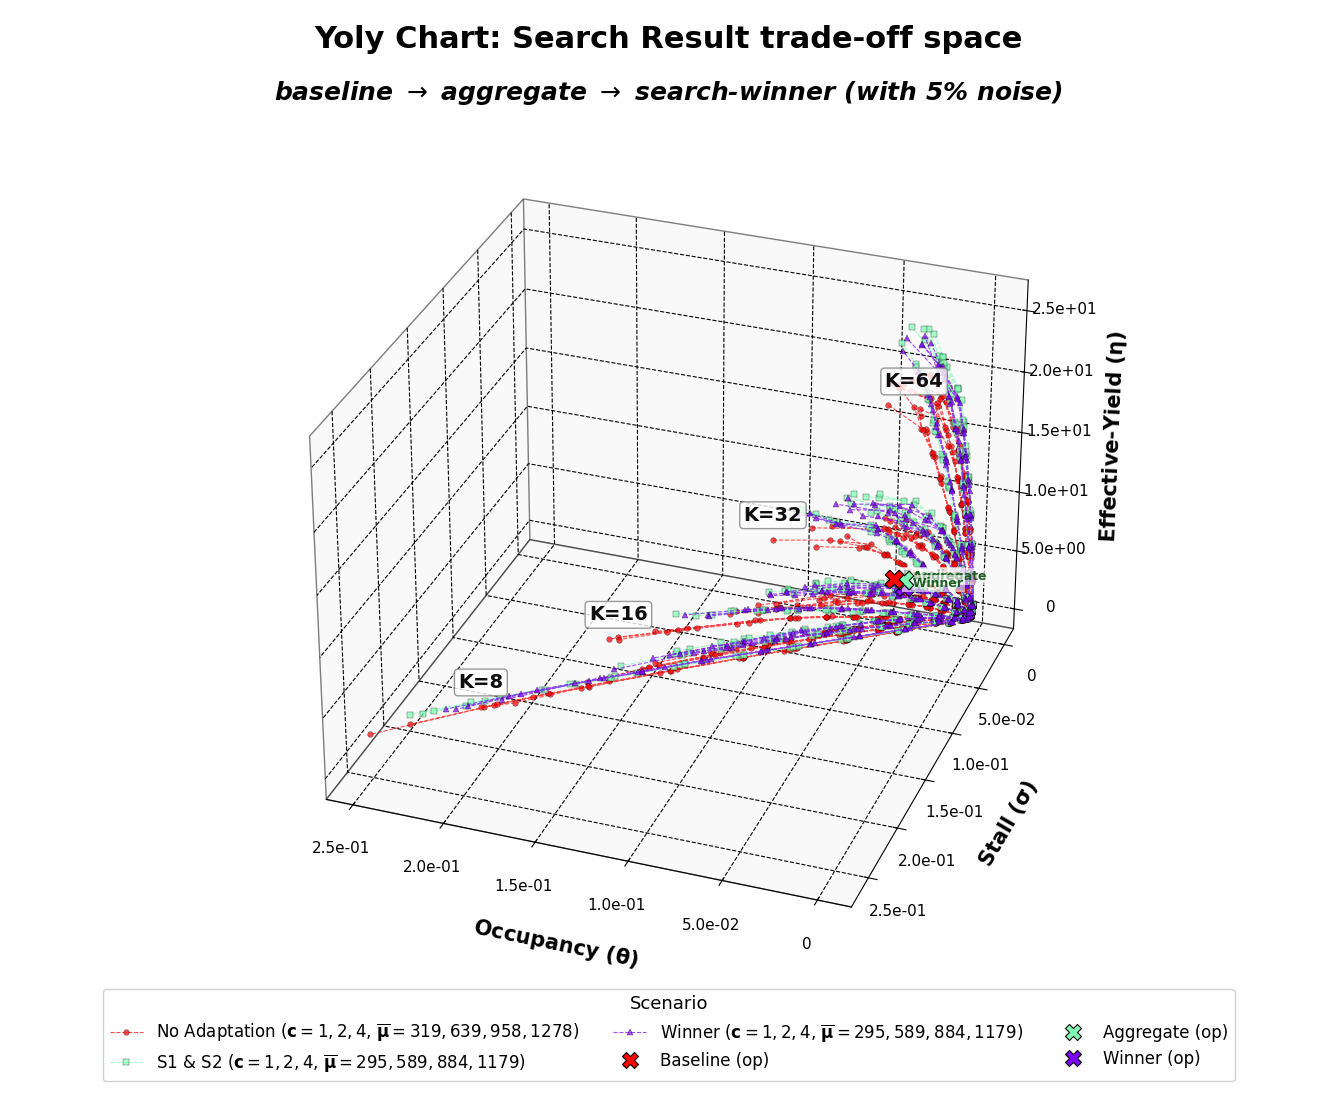

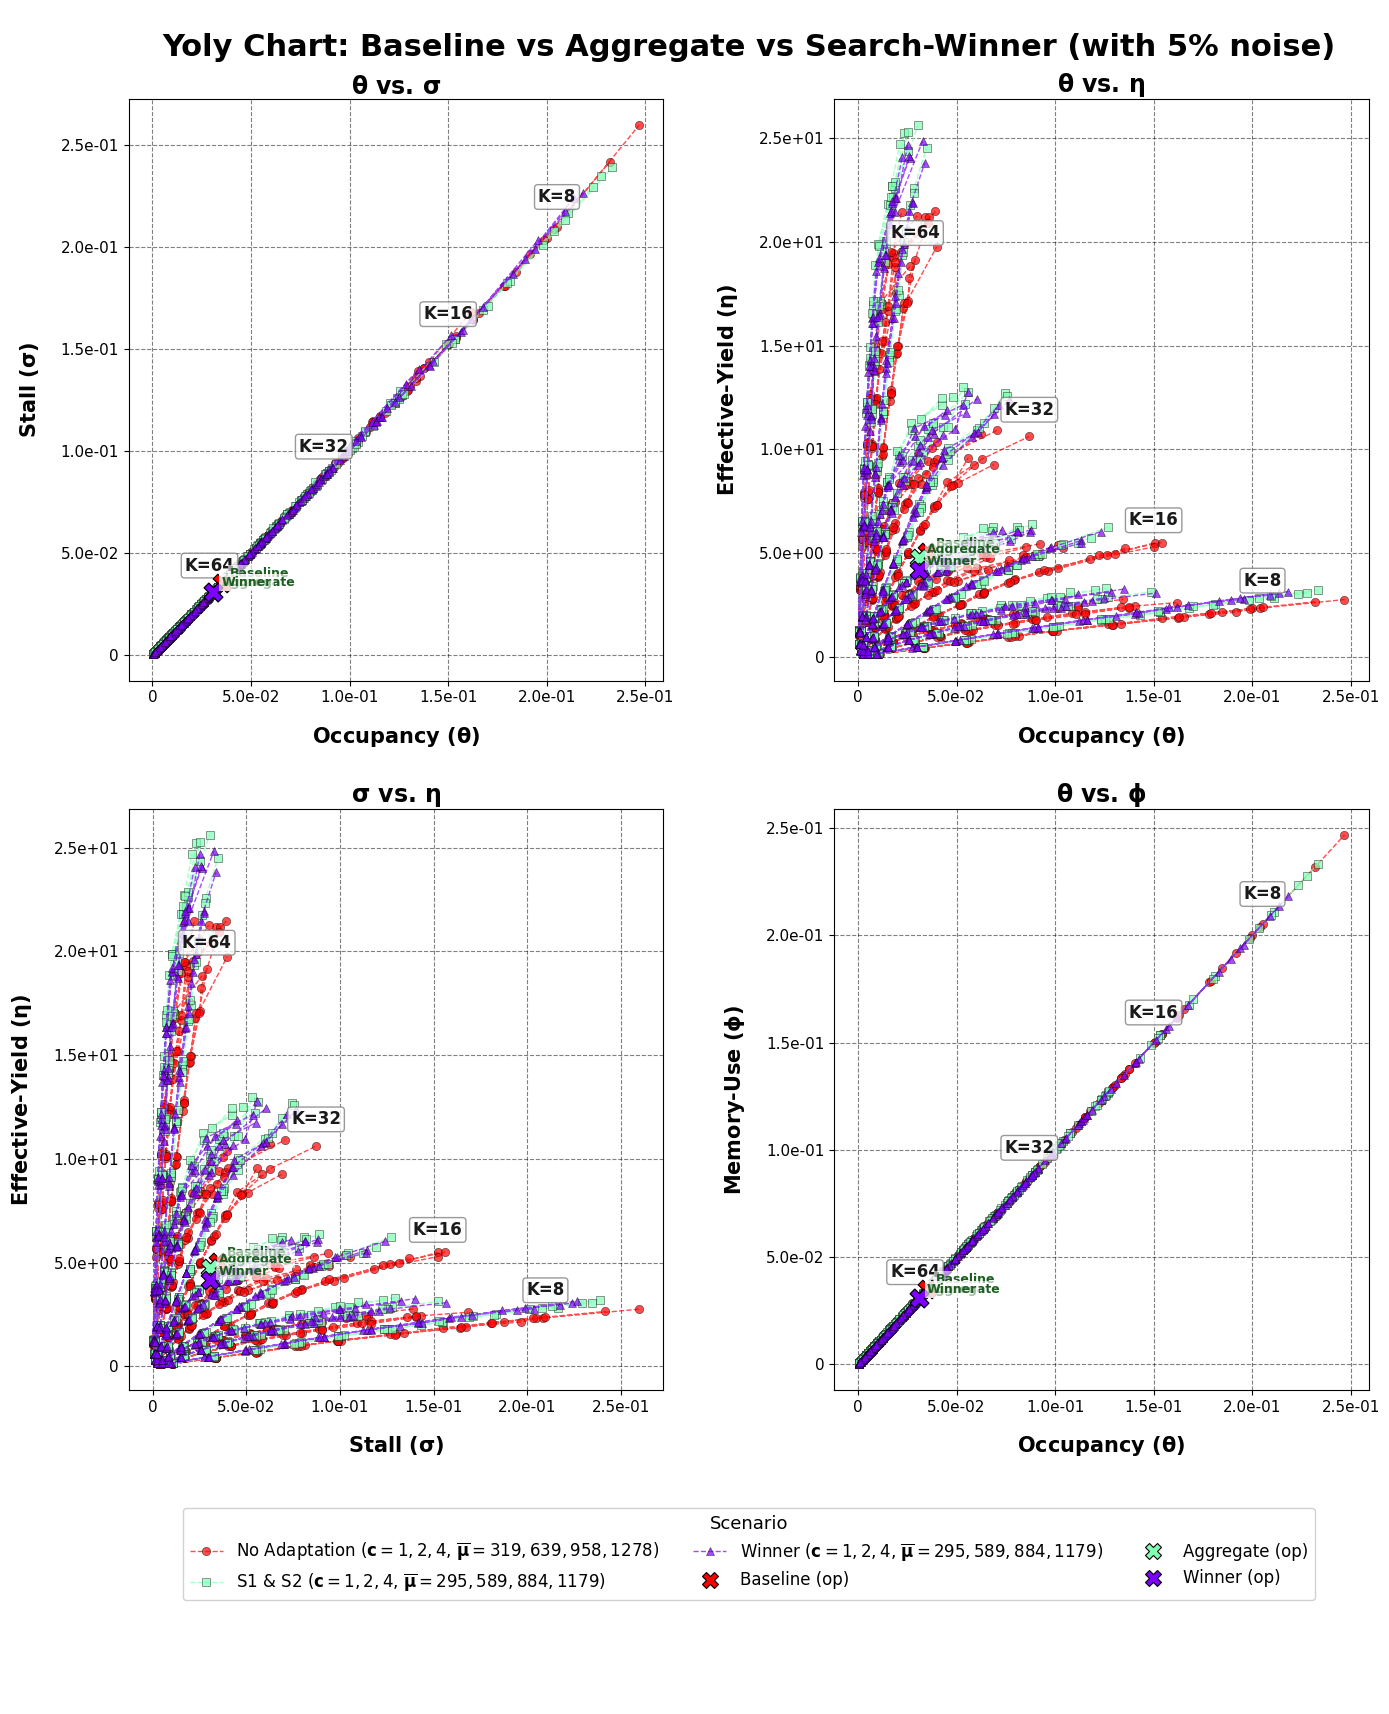

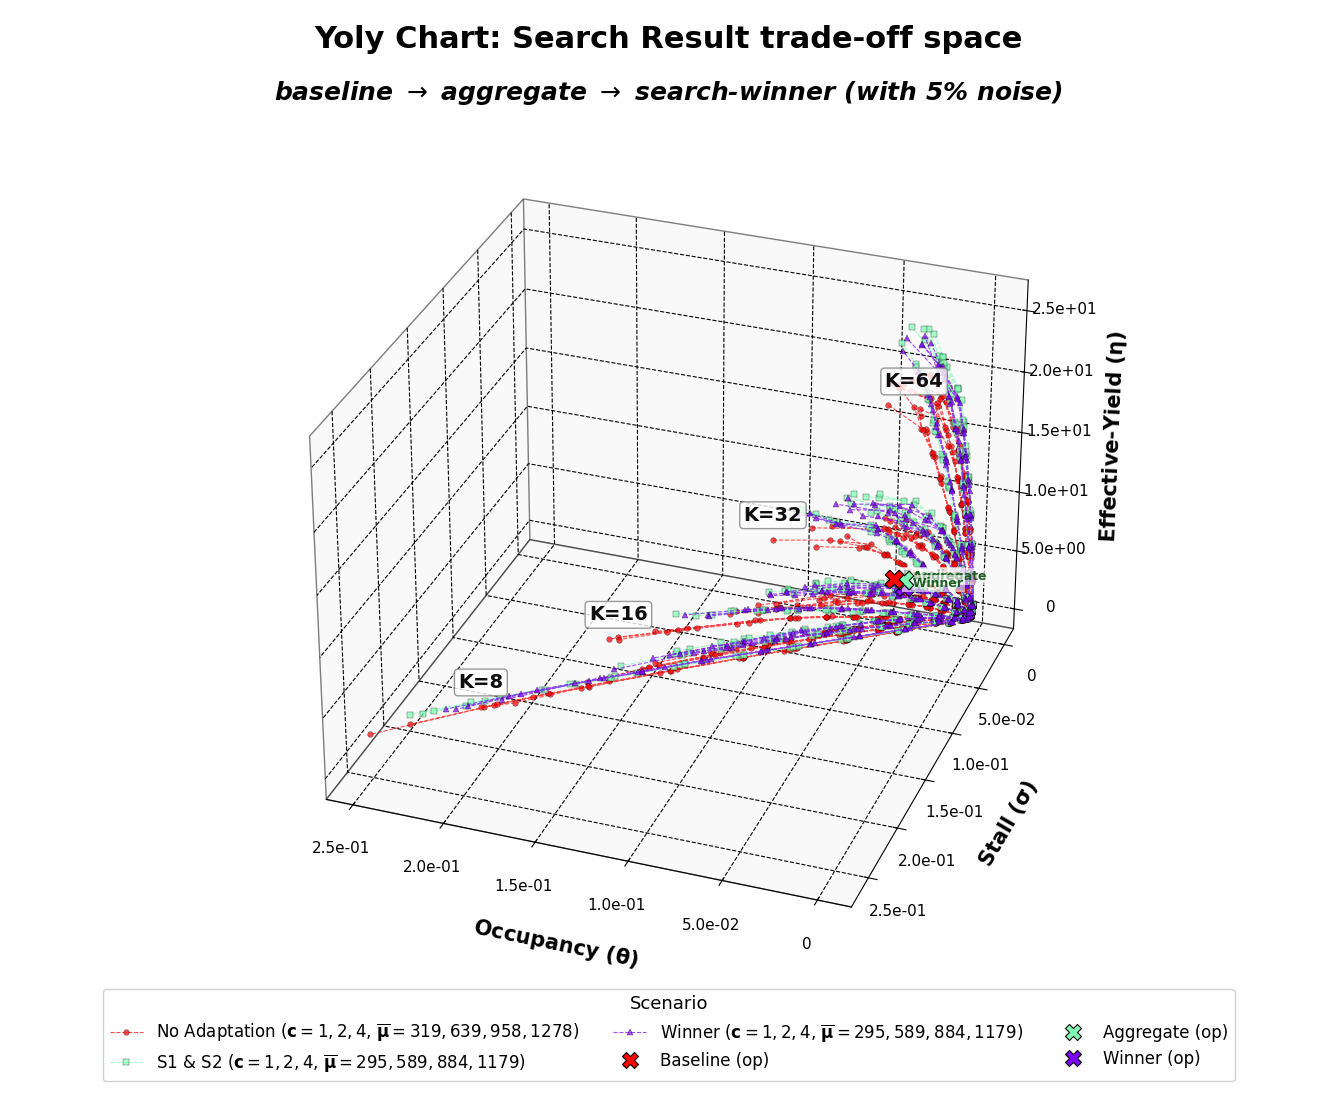

In [8]:
sweep_grid = method_cfg["sweep_grid"]
SEED = method_cfg.get("seed")  # seeds the display-only white noise so the clouds are reproducible

# Sweep baseline + aggregate (reference) and the winner. Clouds carry seeded 5% white noise on
# the independent variables (mirrors 04-yoly). The baseline/aggregate op-point stars are loaded
# from the robust dimensional solution (03 section 1) so they carry the same 5% coefficient noise;
# the winner op-point is computed clean (the search selection is noise-free).
sweeps = {}
archs = {}
for a in ("baseline", "aggregate"):
    cfg_a = load_profile(adaptation=a)
    sweeps[a] = sweep_arch(cfg_a,
                           sweep_grid,
                           noise=NOISE,
                           seed=SEED)
    archs[a] = aggregate_sweep_to_arch(sweeps[a], tag=f"TAS_{a}")

winner_weights = {
    "M": tuple(winner["w_M"]),
    "A": tuple(winner["w_A"]),
    "D": tuple(winner["w_D"])
}

winner_cfg = build_cfg(catalogue,
                       pools,
                       winner_weights,
                       lam_z=LAM_Z, tas_artifacts=tas_artifacts, template=template,
                       retry=winner_retry)

sweeps["winner"] = sweep_arch(winner_cfg,
                              sweep_grid,
                              noise=NOISE,
                              seed=SEED)
archs["winner"]  = aggregate_sweep_to_arch(sweeps["winner"],
                                           tag="TAS_winner")

# baseline/aggregate op-points come from the robust dimensional solution on disk (03 section 1),
# so they carry the 5% coefficient noise; the winner op-point is recomputed clean below (the
# search selection and the persisted winner stay noise-free).
op_points = load_dim_op_points(["baseline", "aggregate"])
winner_dim = run_from_netcfg(winner_cfg,
                             wrt=False,
                             method_cfg=method_cfg)
winner_arch_df = aggregate_arch_coefs(winner_dim,
                                      tag="TAS_winner")

op_points["winner"] = {
    "theta": float(winner_arch_df.iloc[0]["\\theta_{TAS_winner}"]),
    "sigma": float(winner_arch_df.iloc[0]["\\sigma_{TAS_winner}"]),
    "eta": float(winner_arch_df.iloc[0]["\\eta_{TAS_winner}"]),
    "phi": float(winner_arch_df.iloc[0]["\\phi_{TAS_winner}"]),
}

overlay = {
    **archs["baseline"],
    **archs["aggregate"],
    **archs["winner"]
}
scenarios = {
    DISPLAY["baseline"]: "TAS_baseline",
    DISPLAY["aggregate"]: "TAS_aggregate",
    "Winner": "TAS_winner",
}

plot_yoly_with_op_points(overlay,
                         op_points,
                         kind="chart",
                         scenarios=scenarios,
                         legend_ncol_cap=3,
                         title="Yoly Chart: Baseline vs Aggregate vs Search-Winner (with 5% noise)",
                         file_path=str(IMG_ROOT),
                         fname="yc_winner_overlay.png",
)
plot_yoly_with_op_points(overlay,
                         op_points,
                         kind="space",
                         scenarios=scenarios,
                         legend_ncol_cap=3,
                         title="Yoly Chart: Search Result trade-off space",
                         subtitle=r"baseline $\to$ aggregate $\to$ search-winner (with 5% noise)",
                         file_path=str(IMG_ROOT),
                         fname="sb_winner_overlay.png",
)

## 8. The search cloud: selection surface and Pareto front

The coarse dispatch x retry grid (`run_search` at step 0.1, swept under each retry configuration and pooled) is the search's candidate cloud. It is built once below, then read two ways: section 8a plots it in the **requirement frame** $(\sigma_{\text{arch}}, \eta_{\text{arch}})$ with the DASA viable box and selects the winner as the deepest-in-box point; section 8b plots the same cloud in the $(\varepsilon_{e2e}, W_{e2e})$ objective axes with the non-dominated Pareto front. This cloud also feeds the confusion matrix in section 9.

In [9]:
# trade-off cloud_df: a coarse dispatch grid under each retry config, pooled and coloured by
# retry. Reused by the confusion matrix in section 9.
cloud_parts = []
for retry in RETRY_GRID:
    part = run_search(
        catalogue,
        pools,
        lam_z=LAM_Z,
        tas_artifacts=tas_artifacts,
        template=template,
        bounds=bounds,
        step=0.1,
        rho_max=RHO_MAX,
        retry=retry,
    )
    if retry:
        part["retry_label"] = "+".join(sorted(retry))
    else:
        part["retry_label"] = "selection-only"
    cloud_parts.append(part)
cloud_df = pd.concat(cloud_parts, ignore_index=True)


### 8a. DASA selection surface: the cloud, the box, the winner

Each candidate is one point in the requirement frame $(\sigma_{\text{arch}}, \eta_{\text{arch}})$, the coordinate where the DASA viable box is defined: $\sigma_{\text{arch}} < \sigma_{R2}$ is R2 and $\eta_{\text{arch}} < \eta_{R1}$ is R1. The winner is the cloud point that lands deepest inside that box (largest DC margin); `select_from_cloud` makes the pick explicit. The fine descent (sections 3-6) refines the same pick to 0.001 weight resolution, so the persisted winner (the star) is the high-resolution point inside the box. The table confirms the coarse-cloud pick and the persisted fine winner coincide: the search navigates the cloud into the viable region, and the descent only sharpens the basin the cloud already locates.

This is the requirement frame, distinct from the sum-frame yoly chart of section 7: there the architecture's coefficient-space trajectory is shown; here the viable box is numerically valid because $\sigma_{\text{arch}}$ and $\eta_{\text{arch}}$ use the same $K_{\min}$ / $\mu_{\min}$ reference the bounds do.

,retry,sigma_arch,eta_arch,eps_e2e [%],W_e2e [ms],status
pick,,,,,,
coarse cloud (step 0.1),TAS_{4}+TAS_{5}+TAS_{6},0.3873,34.4679,0.0423,19.1871,feasible
fine descent (persisted),TAS_{4}+TAS_{5}+TAS_{6},0.4007,34.4633,0.0290,19.8501,feasible


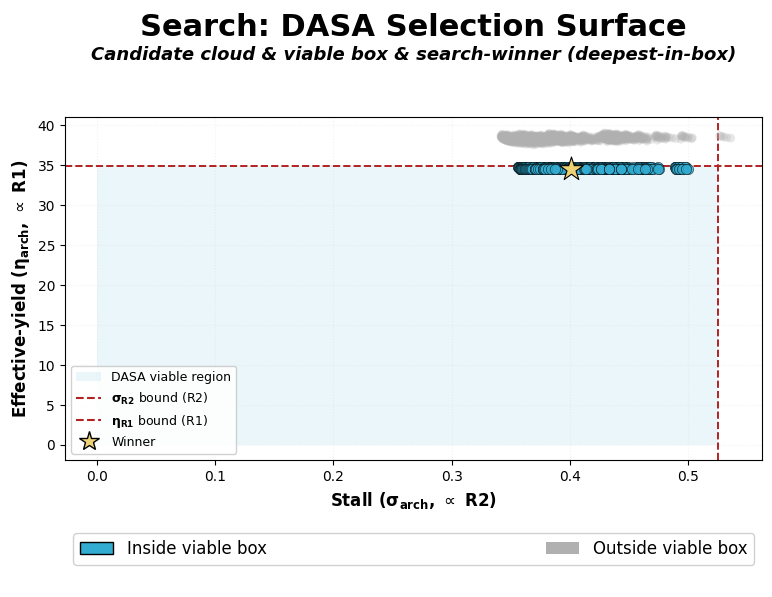

In [10]:
# The coarse cloud is the selection surface; the winner is the deepest-in-box point of it.
# select_from_cloud names that pick (it is pick_winner over the cloud). The persisted winner
# (the star) comes from the fine descent in section 6; the table confirms the two coincide.
cloud_surface = cloud_to_selection_surface(cloud_df,
                                           tag="req")
cloud_winner = select_from_cloud(cloud_df, bounds)

# align the in-box mask to the finite surface rows (cloud_to_selection_surface drops the
# inf-placeholder rows left by short-circuited candidates)
finite = cloud_df["sigma_arch"].apply(np.isfinite) & cloud_df["eta_arch"].apply(np.isfinite)
feasible = (
    cloud_df["stable"]
    & cloud_df["rho_pass"]
    & cloud_df["dasa_pass"]
    & cloud_df["r1_pass"]
    & cloud_df["r2_pass"]
)
feasible_mask = feasible[finite].to_numpy()

plot_selection_surface(
    cloud_surface,
    bounds,
    winner={
        "sigma_arch": float(winner["sigma_arch"]),
        "eta_arch": float(winner["eta_arch"]),
    },
    feasible_mask=feasible_mask,
    title="Search: DASA Selection Surface",
    subtitle="Candidate cloud & viable box & search-winner (deepest-in-box)",
    file_path=str(IMG_ROOT),
    fname="selection_surface",
)

# coarse-cloud pick vs persisted fine-descent winner: confirm they coincide (the fine descent
# only sharpens the basin the coarse cloud already locates)
agree_df = pd.DataFrame(
    [
        {
            "pick": "coarse cloud (step 0.1)",
            "retry": cloud_winner["retry_label"],
            "sigma_arch": cloud_winner["sigma_arch"],
            "eta_arch": cloud_winner["eta_arch"],
            "eps_e2e [%]": cloud_winner["eps_e2e"] * 100,
            "W_e2e [ms]": cloud_winner["W_e2e"] * 1000,
            "status": cloud_winner["winner_status"],
        },
        {
            "pick": "fine descent (persisted)",
            "retry": winner["retry_label"],
            "sigma_arch": winner["sigma_arch"],
            "eta_arch": winner["eta_arch"],
            "eps_e2e [%]": winner["eps_e2e"] * 100,
            "W_e2e [ms]": winner["W_e2e"] * 1000,
            "status": winner["winner_status"],
        },
    ]
).set_index("pick")
agree_df.round(4)

### 8b. Pareto front: the R1 vs R2 trade-off

The same cloud in objective axes. Each point is one candidate at $(\varepsilon_{e2e}, W_{e2e})$, coloured by its retry configuration; the black line is the non-dominated Pareto front (no candidate is better on both axes) and the star is the winner. Selection-only candidates cluster at high $\varepsilon_{e2e}$ (right of the R1 bound); retry shifts the whole cloud, and the front, left across the bound.

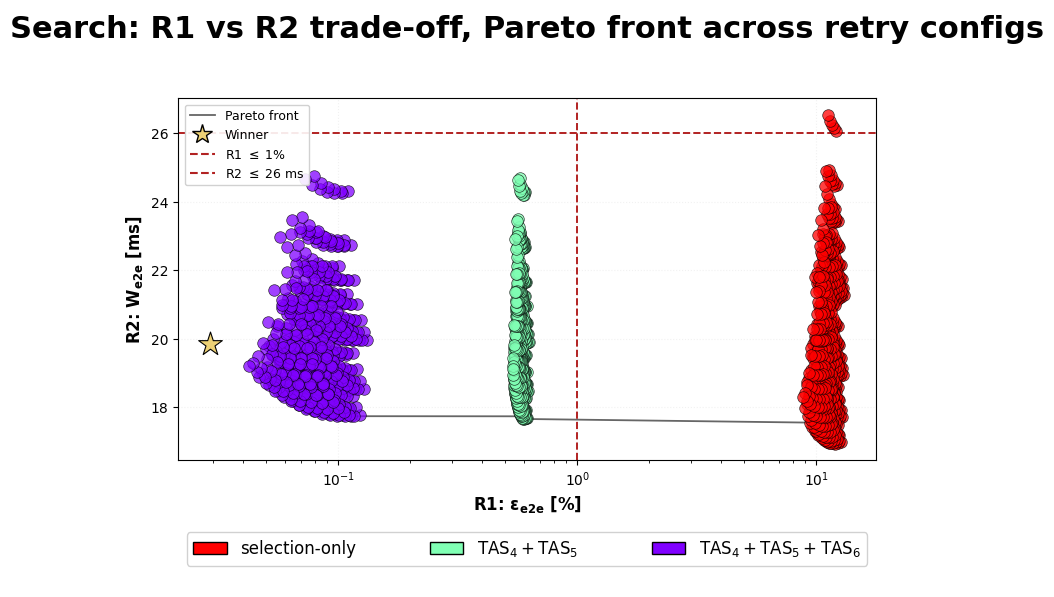

In [11]:
feasible_cloud = cloud_df[cloud_df["stable"] & cloud_df["rho_pass"]].copy()

# Render the retry tokens with proper LaTeX subscripts in the legend: wrap each TAS_{i} in
# mathtext so "TAS_{4}+TAS_{5}" shows as TAS with subscripts, not literal braces. retry_label
# itself stays plain so the section 4 and 8a tables keep reading cleanly.
RETRY_DISP = {
    "selection-only": "selection-only",
    "TAS_{4}+TAS_{5}": r"$\mathrm{TAS}_{4}+\mathrm{TAS}_{5}$",
    "TAS_{4}+TAS_{5}+TAS_{6}": r"$\mathrm{TAS}_{4}+\mathrm{TAS}_{5}+\mathrm{TAS}_{6}$",
}
feasible_cloud["retry_disp"] = feasible_cloud["retry_label"].map(RETRY_DISP)

plot_pareto_front(
    feasible_cloud,
    x_col="eps_e2e",
    y_col="W_e2e",
    group_col="retry_disp",
    x_scale=100.0,
    y_scale=1000.0,
    x_log=True,
    x_label=r"R1: $\mathbf{\varepsilon_{e2e}}$ [%]",
    y_label=r"R2: $\mathbf{W_{e2e}}$ [ms]",
    x_threshold=R1_MAX,
    y_threshold=R2_MAX_S,
    x_threshold_label=r"R1 $\leq$ 1%",
    y_threshold_label=r"R2 $\leq$ 26 ms",
    winner_xy=(winner["eps_e2e"], winner["W_e2e"]),
    title="Search: R1 vs R2 trade-off, Pareto front across retry configs",
    file_path=str(IMG_ROOT),
    fname="pareto_r1_r2",
);

## 9. Confusion matrix: do DASA bounds predict R1 + R2?

Across the full trade-off cloud (every retry configuration, ~3.9k candidates), rows = DASA prediction ($\sigma_{\text{arch}} < \sigma_{R2} \wedge \eta_{\text{arch}} < \eta_{R1}$) and columns = the analytic R1 + R2 verdict. With $K_{\min}$, $c_{\min}$, $\mu_{\min}$ held constant the DASA inequality reduces algebraically to R1 AND R2, so the bounds should predict the verdict on every candidate, over a region that contains both passes and fails.

In [12]:
# DASA prediction vs the analytic R1 + R2 verdict across the full trade-off cloud
ansys_pass = cloud_df["r1_pass"] & cloud_df["r2_pass"]
dasa_pass = cloud_df["dasa_pass"]

tp = int((dasa_pass & ansys_pass).sum())
fp = int((dasa_pass & ~ansys_pass).sum())
fn = int((~dasa_pass & ansys_pass).sum())
tn = int((~dasa_pass & ~ansys_pass).sum())
total = tp + fp + fn + tn

conf_df = pd.DataFrame(
    [
        [tp, fp],
        [fn, tn],
    ],
    index=["DASA PASS", "DASA FAIL"],
    columns=["analytic PASS", "analytic FAIL"],
)
display(conf_df)

prec = float("nan")
if (tp + fp) > 0:
    prec = tp / (tp + fp)
recall = float("nan")
if (tp + fn) > 0:
    recall = tp / (tp + fn)
scores = pd.DataFrame(
    [
        {"metric": "candidates", "value": total},
        {"metric": "accuracy", "value": (tp + tn) / total},
        {"metric": "precision", "value": prec},
        {"metric": "recall", "value": recall},
    ]
).set_index("metric")
scores.round(4)

,analytic PASS,analytic FAIL
DASA PASS,1470,0
DASA FAIL,0,2418


,value
metric,
candidates,3888.0
accuracy,1.0
precision,1.0
recall,1.0


## 10. Side-by-side: aggregate (published) vs winner (search)

Does the searched winner improve on the hand-authored aggregate? Both should clear R1 and R2; the comparison shows which dominates on $\varepsilon_{e2e}$ (availability) and $W_{e2e}$ (performance) and where each sits on the yoly coefficients.

In [13]:
agg_cfg = load_profile(adaptation="aggregate")
agg_dim = run_from_netcfg(agg_cfg,
                          wrt=False,
                          method_cfg=method_cfg)
agg_net = agg_dim["network"].iloc[0]
agg_req = agg_dim["requirements"]
agg_arch = aggregate_arch_coefs(agg_dim, tag="TAS_aggregate").iloc[0]
verdict = {
    True: "PASS",
    False: "FAIL",
}

# winner DASA coefficients come from op_points["winner"] (PyDASA-derived, same basis as agg_arch)
cmp_df = pd.DataFrame(
    {
        "aggregate (published)": {
            "W_e2e [ms]": round(agg_net["W_e2e"] * 1000, 3),
            "eps_e2e [%]": round(agg_net["eps_e2e"] * 100, 4),
            "R1 (eps <= 1%)": verdict[agg_req["R1"]["pass"]],
            "R2 (W <= 26 ms)": verdict[agg_req["R2"]["pass"]],
            "theta_arch": round(float(agg_arch["\\theta_{TAS_aggregate}"]), 4),
            "sigma_arch": round(float(agg_arch["\\sigma_{TAS_aggregate}"]), 4),
            "eta_arch": round(float(agg_arch["\\eta_{TAS_aggregate}"]), 4),
            "phi_arch": round(float(agg_arch["\\phi_{TAS_aggregate}"]), 4),
        },
        "winner (search)": {
            "W_e2e [ms]": round(winner["W_e2e"] * 1000, 3),
            "eps_e2e [%]": round(winner["eps_e2e"] * 100, 4),
            "R1 (eps <= 1%)": verdict[winner["r1_pass"]],
            "R2 (W <= 26 ms)": verdict[winner["r2_pass"]],
            "theta_arch": round(op_points["winner"]["theta"], 4),
            "sigma_arch": round(op_points["winner"]["sigma"], 4),
            "eta_arch": round(op_points["winner"]["eta"], 4),
            "phi_arch": round(op_points["winner"]["phi"], 4),
        },
    }
)
cmp_df

,aggregate (published),winner (search)
W_e2e [ms],19.401,19.85
eps_e2e [%],0.0714,0.029
R1 (eps <= 1%),PASS,PASS
R2 (W <= 26 ms),PASS,PASS
theta_arch,0.0292,0.0308
sigma_arch,0.0292,0.0308
eta_arch,4.1468,4.1621
phi_arch,0.0292,0.0308


## 11. Winner robustness under 5% white noise

The winner was selected and verified on clean data (sections 3-6). This section re-evaluates *that same winner* under seeded 5% white noise on the M/M/c/K **independent** variables ($\lambda$, $\mu$, $\varepsilon$) via `run_from_netcfg(winner_cfg, noise=NOISE)` (default `noise_scope="all"`, so the perturbation reaches the verdict). This is a fuller stress than the coefficient-only noise baked into `03-dimensional` section 1 and `04-yoly`: here it perturbs the end-to-end metrics and R1 / R2 verdict, not just the coefficients. It compares the winner's end-to-end metrics and R1 / R2 verdict against the clean run. The question: does the feasible winner stay inside both requirement bounds when its inputs are perturbed 5%? The selection itself is untouched, this is a robustness readout, not a re-search.

In [14]:
# Re-evaluate the chosen winner under seeded 5% input noise (same independent-variable
# perturbation as 03 / 04). winner_dim (clean) was computed in section 7; the SELECTION is
# unchanged. This only asks whether the feasible winner survives 5% noise on lambda/mu/epsilon.
winner_noisy = run_from_netcfg(winner_cfg,
                               wrt=False,
                               method_cfg=method_cfg,
                               noise=NOISE)

clean_net = winner_dim["network"].iloc[0]
clean_req = winner_dim["requirements"]
noisy_net = winner_noisy["network"].iloc[0]
noisy_req = winner_noisy["requirements"]

clean_arch = aggregate_arch_coefs(winner_dim, tag="TAS_winner").iloc[0]
noisy_arch = aggregate_arch_coefs(winner_noisy, tag="TAS_winner").iloc[0]

verdict = {
    True: "PASS",
    False: "FAIL",
}

robust_df = pd.DataFrame(
    {
        "winner (clean)": {
            "W_e2e [ms]": round(clean_net["W_e2e"] * 1000, 3),
            "eps_e2e [%]": round(clean_net["eps_e2e"] * 100, 4),
            "R1 (eps <= 1%)": verdict[clean_req["R1"]["pass"]],
            "R2 (W <= 26 ms)": verdict[clean_req["R2"]["pass"]],
            "sigma_arch": round(float(clean_arch["\\sigma_{TAS_winner}"]), 4),
            "eta_arch": round(float(clean_arch["\\eta_{TAS_winner}"]), 4),
        },
        f"winner ({int(NOISE * 100)}% noise)": {
            "W_e2e [ms]": round(noisy_net["W_e2e"] * 1000, 3),
            "eps_e2e [%]": round(noisy_net["eps_e2e"] * 100, 4),
            "R1 (eps <= 1%)": verdict[noisy_req["R1"]["pass"]],
            "R2 (W <= 26 ms)": verdict[noisy_req["R2"]["pass"]],
            "sigma_arch": round(float(noisy_arch["\\sigma_{TAS_winner}"]), 4),
            "eta_arch": round(float(noisy_arch["\\eta_{TAS_winner}"]), 4),
        },
    }
)
still_feasible = noisy_req["R1"]["pass"] and noisy_req["R2"]["pass"]
print(f"winner stays feasible under {int(NOISE * 100)}% input noise: {still_feasible}")
robust_df

winner stays feasible under 5% input noise: True


,winner (clean),winner (5% noise)
W_e2e [ms],19.85,20.753
eps_e2e [%],0.029,0.029
R1 (eps <= 1%),PASS,PASS
R2 (W <= 26 ms),PASS,PASS
sigma_arch,0.0308,0.0327
eta_arch,4.1621,4.2527


## 12. Persist the winner

Write the winner's network + requirements JSON envelope under `data/results/search/winner/` (consumed by `06-comparison.ipynb` as a 5th solution), plus the full descent + scipy frames for inspection. The winner's dimensional envelope lands under `data/results/dimensional/winner/`. This is the **clean** winner (no noise); the section-11 robustness readout is in-memory only and writes nothing.

In [15]:
winner_dir = RESULTS_ROOT / "winner"
winner_dir.mkdir(parents=True, exist_ok=True)

winner_doc = {
    "pools": pools,
    "weights": {
        "MAS": list(winner["w_M"]),
        "AS": list(winner["w_A"]),
        "DS": list(winner["w_D"]),
    },
    "retry": winner_retry,
    "metrics": {
        "W_e2e_ms": float(winner["W_e2e"]) * 1000,
        "eps_e2e": float(winner["eps_e2e"]),
        "sigma_arch": float(winner["sigma_arch"]),
        "eta_arch": float(winner["eta_arch"]),
    },
    "bounds": bounds,
    "winner_status": winner["winner_status"],
    "scipy_validation": {
        "retry": scipy_winner["retry"],
        "W_e2e_ms": float(scipy_winner["W_e2e"]) * 1000,
        "eps_e2e": float(scipy_winner["eps_e2e"]),
        "abs_dW_e2e_ms": float(dW),
        "abs_deps_e2e_pp": float(de),
        "same_retry": bool(same_retry),
    },
}
(winner_dir / "winner.json").write_text(json.dumps(winner_doc, indent=4), encoding="utf-8")

# Full frames for inspection. Tuple / dict columns are coerced so the JSON serialiser accepts them.
def _frame_to_json(frame, path):
    out = frame.copy()
    for col in ("w_M", "w_A", "w_D"):
        out[col] = out[col].apply(list)
    if "retry" in out.columns:
        out["retry"] = out["retry"].apply(lambda r: dict(r) if r else {})
    out.to_json(path, orient="records", indent=2)

_frame_to_json(descent_df, winner_dir / "search.json")
_frame_to_json(scipy_df, winner_dir / "scipy.json")

# Persist the winner's full dimensional envelope (network + requirements + per-artifact coefficients).
winner_run = run_from_netcfg(winner_cfg, wrt=True, method_cfg=method_cfg)
print(f"wrote winner.json + search.json + scipy.json under {winner_dir}/")
for k, p in winner_run.get("paths", {}).items():
    print(f"  {k}: {p}")

wrote winner.json + search.json + scipy.json under data\results\search\winner/
  profile: data\results\dimensional\winner\search.json
  requirements: data\results\dimensional\winner\requirements.json


## Summary

Navigating the design space by DASA's dimensionless coefficients, the DC-guided descent finds a configuration that satisfies both requirements and improves on the hand-authored aggregate. The winner concentrates dispatch on the lowest-$\varepsilon$ service variant in each pool ($\mathrm{MAS}_2$, $\mathrm{AS}_2$) with retry ($k = 3$) enabled on all three workflow handlers: $\varepsilon_{e2e} \approx 0.029\%$ (R1 PASS, about 2.5x better than the aggregate's $0.07\%$) at $W_{e2e} \approx 19.85$ ms (R2 PASS). Both the winner and the aggregate clear both bounds; the searched winner buys extra availability margin for a negligible performance cost.

The **retry axis** is the binding lever (section 4): selection-only dispatch cannot clear R1 at any weighting (the per-service $\varepsilon$ catalogue is the floor), but retry on the availability-binding handlers drives the leaked flow below 1%. The **Pareto front** (section 8) makes the R1-vs-R2 trade-off explicit: selection-only optima sit far to the right (high $\varepsilon_{e2e}$), and retry pulls the non-dominated frontier left across the R1 bound.

Two independent results close the loop:

- **External validation (section 5):** an off-the-shelf optimiser (`scipy.optimize`, COBYLA) re-optimising the same bi-objective lands on the same retry configuration and the same operating point as the DASA-native descent (agreement within a small fraction of a millisecond on $W_{e2e}$ and effectively zero on $\varepsilon_{e2e}$). The custom coefficient-guided search is cross-validated against standard tooling, and PyDASA's coefficients integrate cleanly as the objective an external optimiser minimises.
- **Predictive payoff (section 9):** across the 1,296-candidate coarse grid under the winning retry config, DASA's dimensionless bounds predict the analytic R1 + R2 verdict on every candidate (100% accuracy), now over a region containing both passes and fails, not just an empty one.

This is the dissertation's constructive demonstration: the dimensionless coefficients are both a sufficient compass for navigating the design space and an accurate predictor of the feasible region, and an independent optimiser confirms the configuration they lead to. The winner is persisted for `06-comparison.ipynb`, which places it alongside the four published adaptations.